<a href="https://colab.research.google.com/github/Namcys/my-first-blog/blob/main/Default_of__Credit__Card_Clients__Binary_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSc Data Science – Machine Learning Project
## Default of Credit Card Clients – Binary Classification

**Dataset:** Yeh, I. (2009). Default of Credit Card Clients. UCI Machine Learning Repository.  
https://doi.org/10.24432/C55S3H  
**Domain:** Economy & Finance  
**Task:** Binary Classification (default = 1 vs non-default = 0)

**Approved Project Proposal:**
*   **Dataset:** Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H
*   **Domain:** Economy and Finance
*   **Task:** Binary Classification (default vs. non-default)
*   **Planned Techniques:**
    *   Dimensionality Reduction: Principal Component Analysis (PCA)
    *   Supervised Learning Model 1: Logistic Regression
    *   Supervised Learning Model 2: Random Forest

## 1. Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, precision_recall_curve,
    average_precision_score, f1_score, accuracy_score
)

import urllib.request
import zipfile, os

sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Acquisition
Download the dataset directly from the UCI ML Repository.

In [ ]:
DATA_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00350/default%20of%20credit%20card%20clients.xls"
)
LOCAL_FILE = "default_of_credit_card_clients.xls"

if not os.path.exists(LOCAL_FILE):
    try:
        print("Downloading from UCI ...")
        urllib.request.urlretrieve(DATA_URL, LOCAL_FILE)
        print(f"Saved: {LOCAL_FILE}")
    except Exception as e:
        print(f"Primary download failed ({e}). Trying ZIP fallback ...")
        ALT_URL = (
            "https://archive.ics.uci.edu/static/public/350/"
            "default+of+credit+card+clients.zip"
        )
        zip_path = "credit_card_data.zip"
        urllib.request.urlretrieve(ALT_URL, zip_path)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(".")
        for f in os.listdir("."):
            if f.endswith(".xls") or f.endswith(".xlsx"):
                LOCAL_FILE = f
                break
        print(f"Extracted: {LOCAL_FILE}")
else:
    print(f"File already exists: {LOCAL_FILE}")

df_raw = pd.read_excel(LOCAL_FILE, header=1)   # row-0 is a secondary header
print(f"Raw shape: {df_raw.shape}")
df_raw.head()

Saved: default_of_credit_card_clients.xls
Raw shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 3. Data Preprocessing


In [ ]:
df = df_raw.copy()

# Rename target
target_col = [c for c in df.columns if "default" in c.lower()][-1]
df.rename(columns={target_col: "DEFAULT"}, inplace=True)

# Drop ID
df.drop(columns=["ID"], errors="ignore", inplace=True)

# Missing values
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.fillna(df.median(numeric_only=True), inplace=True)

# Fix erroneous category codes
# EDUCATION: documented values 1-4; 0, 5, 6 → 4 (other)
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
# MARRIAGE: documented 1-3; 0 → 3 (other)
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

# Feature / target split
X = df.drop(columns=["DEFAULT"])
y = df["DEFAULT"].astype(int)
feature_names = X.columns.tolist()

print(f"\nFeatures : {len(feature_names)}")
print(f"Samples  : {len(y)}")
print(f"Default rate: {y.mean()*100:.1f}%")
print(f"\nClass counts:\n{y.value_counts().rename({0: 'No Default', 1: 'Default'})}")

Missing values per column:
Series([], dtype: int64)

Features : 23
Samples  : 30000
Default rate: 22.1%

Class counts:
DEFAULT
No Default    23364
Default        6636
Name: count, dtype: int64


In [ ]:
# Dataset overview
df.describe().T.style.background_gradient(cmap="Blues")

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.000000,167484.322667,129747.661567,10000.000000,50000.000000,140000.000000,240000.000000,1000000.000000
SEX,30000.000000,1.603733,0.489129,1.000000,1.000000,2.000000,2.000000,2.000000
EDUCATION,30000.000000,1.842267,0.744494,1.000000,1.000000,2.000000,2.000000,4.000000
MARRIAGE,30000.000000,1.557267,0.521405,1.000000,1.000000,2.000000,2.000000,3.000000
AGE,30000.000000,35.485500,9.217904,21.000000,28.000000,34.000000,41.000000,79.000000
PAY_0,30000.000000,-0.016700,1.123802,-2.000000,-1.000000,0.000000,0.000000,8.000000
PAY_2,30000.000000,-0.133767,1.197186,-2.000000,-1.000000,0.000000,0.000000,8.000000
PAY_3,30000.000000,-0.166200,1.196868,-2.000000,-1.000000,0.000000,0.000000,8.000000
PAY_4,30000.000000,-0.220667,1.169139,-2.000000,-1.000000,0.000000,0.000000,8.000000
PAY_5,30000.000000,-0.266200,1.133187,-2.000000,-1.000000,0.000000,0.000000,8.000000


## 4. Exploratory Data Analysis (EDA)

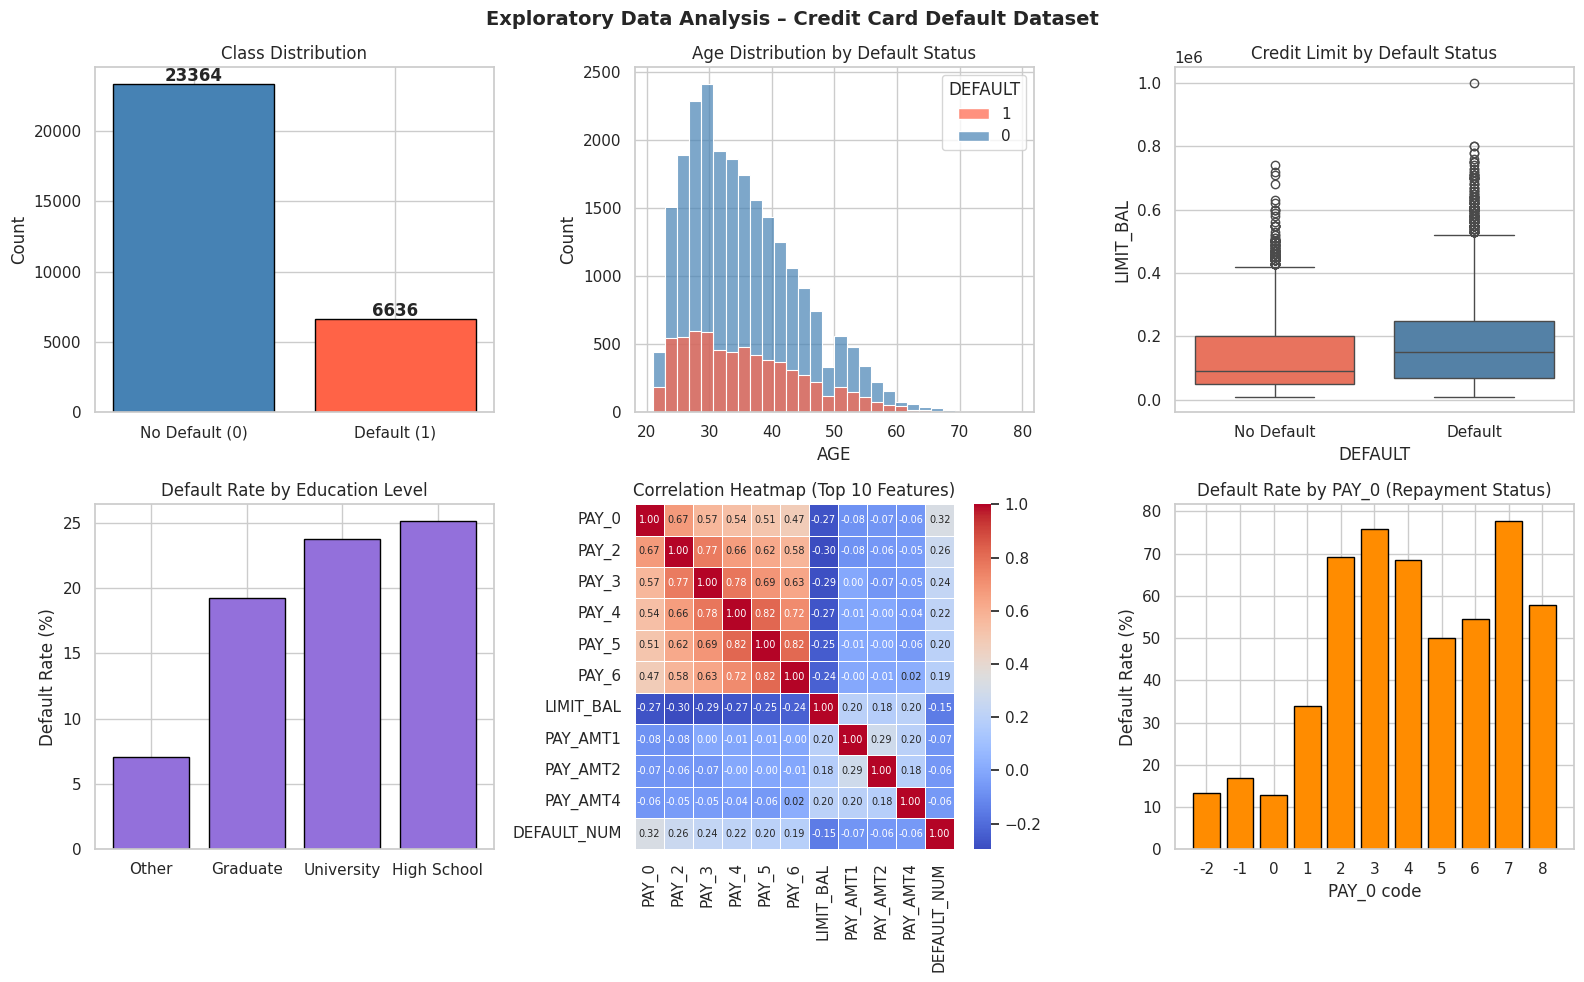

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Exploratory Data Analysis – Credit Card Default Dataset", fontsize=14, fontweight="bold")

# 3-a Class Distribution
axes[0, 0].bar(["No Default (0)", "Default (1)"],
               y.value_counts().sort_index().values,
               color=["steelblue", "tomato"], edgecolor="black")
axes[0, 0].set_title("Class Distribution")
axes[0, 0].set_ylabel("Count")
for i, v in enumerate(y.value_counts().sort_index().values):
    axes[0, 0].text(i, v + 200, str(v), ha="center", fontweight="bold")

# 3-b Age Distribution by Default
df_eda = X.copy()
df_eda["DEFAULT"] = y.values
df_eda["DEFAULT"] = df_eda["DEFAULT"].astype(str) # Convert to string for palette matching
sns.histplot(data=df_eda, x="AGE", hue="DEFAULT", bins=30,
             ax=axes[0, 1], palette={'0': "steelblue", '1': "tomato"}, alpha=0.7)
axes[0, 1].set_title("Age Distribution by Default Status")

# 3-c Credit Limit by Default
sns.boxplot(data=df_eda, x="DEFAULT", y="LIMIT_BAL",
            palette={'0': "steelblue", '1': "tomato"}, ax=axes[0, 2])
axes[0, 2].set_title("Credit Limit by Default Status")
axes[0, 2].set_xticklabels(["No Default", "Default"])

# 3-d Education vs Default Rate
edu_map = {1: "Graduate", 2: "University", 3: "High School", 4: "Other"}
df_eda["EDU_LABEL"] = df_eda["EDUCATION"].map(edu_map)
edu_rate = df_eda.groupby("EDU_LABEL")["DEFAULT"].apply(lambda x: (x == '1').mean()).sort_values() # Adjusted for string '1'
axes[1, 0].bar(edu_rate.index, edu_rate.values * 100, color="mediumpurple", edgecolor="black")
axes[1, 0].set_title("Default Rate by Education Level")
axes[1, 0].set_ylabel("Default Rate (%)")

# 3-e Correlation Heatmap (top 10 features)
# Create a temporary numerical DEFAULT column for correlation calculation
df_eda_corr = df_eda.copy()
df_eda_corr["DEFAULT_NUM"] = df_eda_corr["DEFAULT"].astype(int)
corr = df_eda_corr.drop(columns=["EDU_LABEL", "DEFAULT"]).corr()["DEFAULT_NUM"].drop("DEFAULT_NUM").abs().sort_values(ascending=False)
top_feats = corr.head(10).index.tolist()
corr_matrix = df_eda_corr[top_feats + ["DEFAULT_NUM"]].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[1, 1], linewidths=0.5, annot_kws={"size": 7})
axes[1, 1].set_title("Correlation Heatmap (Top 10 Features)")

# 3-f PAY_0 vs Default Rate
pay_rate = df_eda.groupby("PAY_0")["DEFAULT"].apply(lambda x: (x == '1').mean()) * 100 # Adjusted for string '1'
axes[1, 2].bar(pay_rate.index.astype(str), pay_rate.values, color="darkorange", edgecolor="black")
axes[1, 2].set_title("Default Rate by PAY_0 (Repayment Status)")
axes[1, 2].set_xlabel("PAY_0 code")
axes[1, 2].set_ylabel("Default Rate (%)")

plt.tight_layout()
plt.savefig("01_eda.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Train / Test Split
Stratified 80/20 split to preserve class balance in both sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size : {X_train.shape[0]}  ({y_train.mean()*100:.1f}% default)")
print(f"Test  size : {X_test.shape[0]}   ({y_test.mean()*100:.1f}% default)")

Train size : 24000  (22.1% default)
Test  size : 6000   (22.1% default)


## 6. Dimensionality Reduction — PCA



In [ ]:
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train)
X_test_scaled  = scaler_pca.transform(X_test)

# Full PCA to inspect explained variance
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cum_var >= 0.95) + 1)

print(f"Total features          : {X_train_scaled.shape[1]}")
print(f"Components for 95% var  : {n_components_95}")
print(f"Variance explained      : {cum_var[n_components_95-1]*100:.2f}%")

# Apply chosen PCA
pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
print(f"Reduced shape: {X_train_pca.shape}")

Total features          : 23
Components for 95% var  : 15
Variance explained      : 95.69%
Reduced shape: (24000, 15)


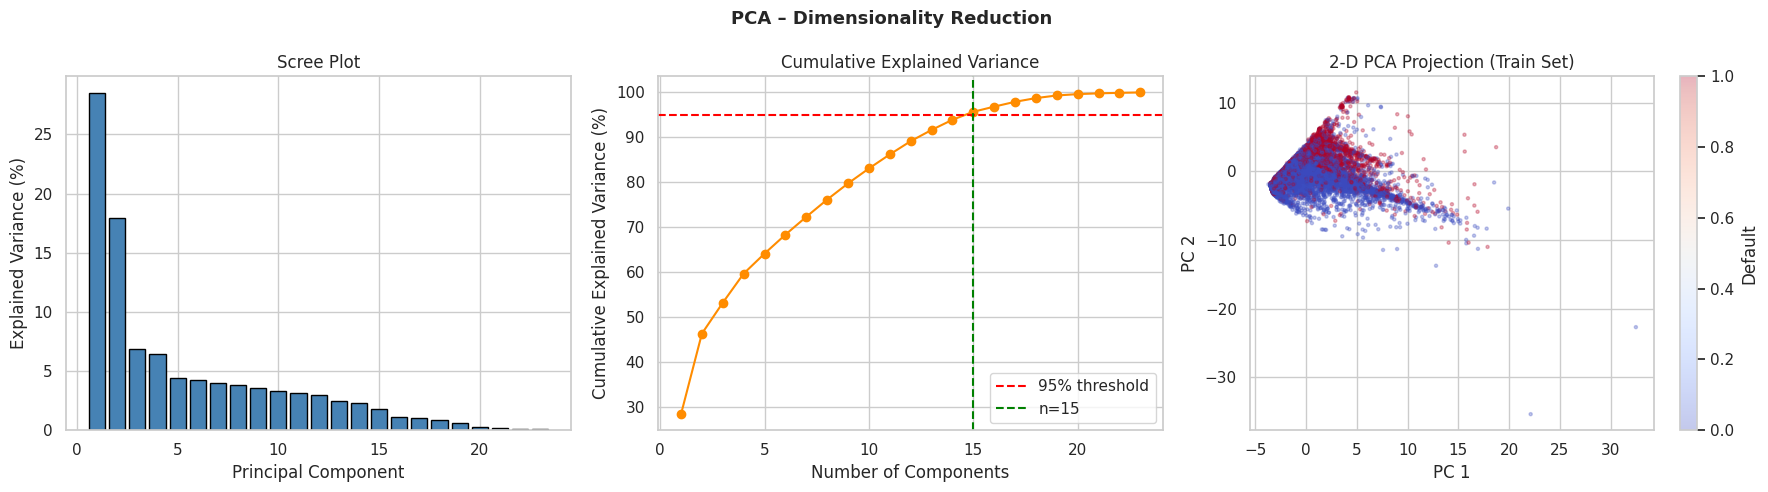

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PCA – Dimensionality Reduction", fontsize=13, fontweight="bold")

# Scree Plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_ * 100,
            color="steelblue", edgecolor="black")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot")

# Cumulative Variance
axes[1].plot(range(1, len(cum_var) + 1), cum_var * 100, "o-", color="darkorange")
axes[1].axhline(95, linestyle="--", color="red", label="95% threshold")
axes[1].axvline(n_components_95, linestyle="--", color="green", label=f"n={n_components_95}")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

# 2D Scatter (PC1 vs PC2)
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2.fit_transform(X_train_scaled)
scatter = axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c=y_train,
                          cmap="coolwarm", alpha=0.3, s=5)
axes[2].set_xlabel("PC 1")
axes[2].set_ylabel("PC 2")
axes[2].set_title("2-D PCA Projection (Train Set)")
plt.colorbar(scatter, ax=axes[2], label="Default")

plt.tight_layout()
plt.savefig("02_pca.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Model 1 — Logistic Regression


In [ ]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=n_components_95, random_state=RANDOM_STATE)),
    ("clf",    LogisticRegression(
                   max_iter=1000,
                   solver="lbfgs",
                   class_weight="balanced",
                   random_state=RANDOM_STATE
               ))
])

# Hyperparameter grid — C is the inverse regularisation strength
lr_param_grid = {
    "clf__C":       [0.001, 0.01, 0.1, 1, 10],
    "clf__penalty": ["l2"],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    refit=True
)
lr_search.fit(X_train, y_train)
best_lr = lr_search.best_estimator_

print(f"Best params : {lr_search.best_params_}")
print(f"Best CV AUC : {lr_search.best_score_:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params : {'clf__C': 0.01, 'clf__penalty': 'l2'}
Best CV AUC : 0.7234


In [ ]:
# 5-fold CV on best LR model
lr_cv_scores = cross_val_score(best_lr, X_train, y_train,
                                cv=cv_strategy, scoring="roc_auc")
print(f"CV ROC-AUC: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"Per-fold  : {np.round(lr_cv_scores, 4)}")

# Test set evaluation
y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, y_prob_lr)
lr_f1  = f1_score(y_test, y_pred_lr)
lr_acc = accuracy_score(y_test, y_pred_lr)

print(f"\n── Test Set Results (Logistic Regression) ──")
print(f"Accuracy : {lr_acc:.4f}")
print(f"F1 Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_auc:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=["No Default", "Default"]))

CV ROC-AUC: 0.7234 ± 0.0104
Per-fold  : [0.7357 0.726  0.7081 0.715  0.732 ]

── Test Set Results (Logistic Regression) ──
Accuracy : 0.6818
F1 Score : 0.4636
ROC-AUC  : 0.7069

              precision    recall  f1-score   support

  No Default       0.87      0.70      0.77      4673
     Default       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.71      6000



## 8. Model 2 — Random Forest Classifier


In [ ]:
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=n_components_95, random_state=RANDOM_STATE)),
    ("clf",    RandomForestClassifier(
                   class_weight="balanced",
                   random_state=RANDOM_STATE,
                   n_jobs=-1
               ))
])

rf_param_dist = {
    "clf__n_estimators":      [100, 200, 300],
    "clf__max_depth":         [None, 10, 20, 30],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf":  [1, 2, 4],
    "clf__max_features":      ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print(f"Best params : {rf_search.best_params_}")
print(f"Best CV AUC : {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params : {'clf__n_estimators': 200, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 4, 'clf__max_features': 'sqrt', 'clf__max_depth': 10}
Best CV AUC : 0.7660


In [ ]:
rf_cv_scores = cross_val_score(best_rf, X_train, y_train,
                                cv=cv_strategy, scoring="roc_auc")
print(f"CV ROC-AUC: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")
print(f"Per-fold  : {np.round(rf_cv_scores, 4)}")

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, y_prob_rf)
rf_f1  = f1_score(y_test, y_pred_rf)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"\n── Test Set Results (Random Forest) ──")
print(f"Accuracy : {rf_acc:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=["No Default", "Default"]))

CV ROC-AUC: 0.7660 ± 0.0061
Per-fold  : [0.7707 0.7693 0.7541 0.7667 0.7692]

── Test Set Results (Random Forest) ──
Accuracy : 0.7885
F1 Score : 0.5224
ROC-AUC  : 0.7619

              precision    recall  f1-score   support

  No Default       0.86      0.86      0.86      4673
     Default       0.52      0.52      0.52      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.69      0.69      6000
weighted avg       0.79      0.79      0.79      6000



## 9. Model Evaluation & Visualisations

### 9-a. Confusion Matrices

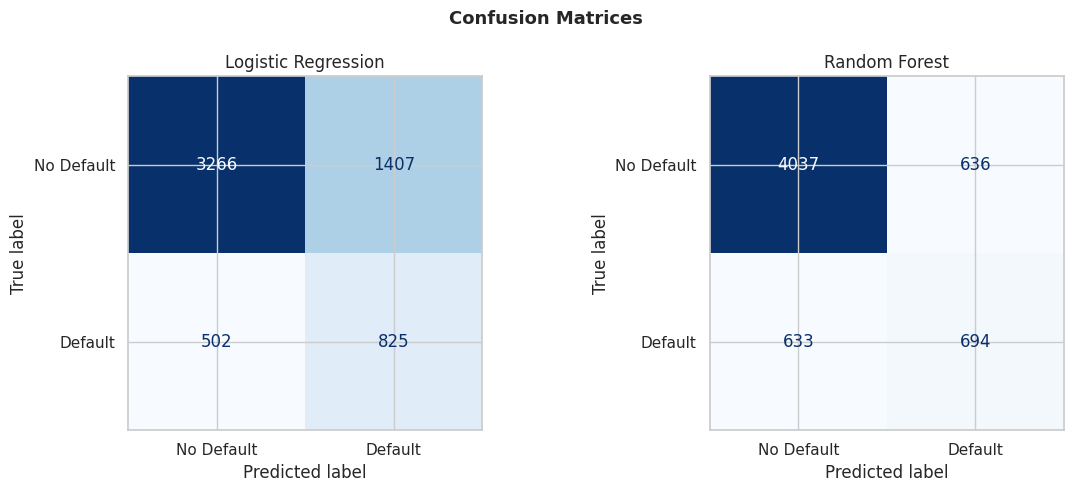

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrices", fontsize=13, fontweight="bold")

for ax, y_pred, title in zip(
        axes,
        [y_pred_lr, y_pred_rf],
        ["Logistic Regression", "Random Forest"]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)

plt.tight_layout()
plt.savefig("03_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### 9-b. ROC Curves

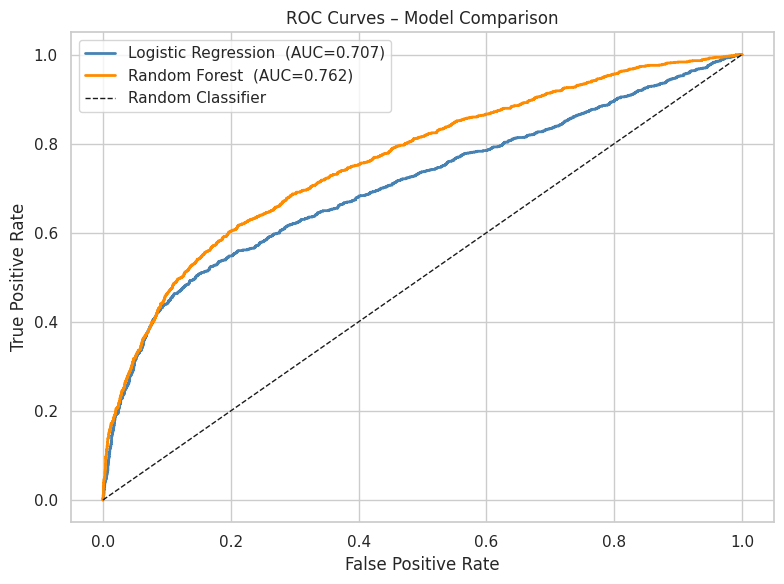

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for y_prob, label, auc_val, color in [
        (y_prob_lr, "Logistic Regression", lr_auc, "steelblue"),
        (y_prob_rf, "Random Forest",       rf_auc, "darkorange")]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{label}  (AUC={auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves – Model Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("04_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 9-c. Precision-Recall Curves

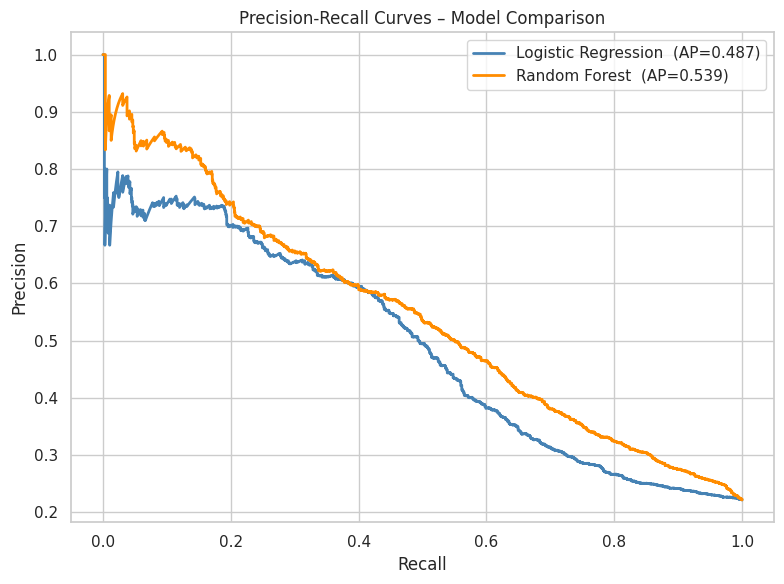

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for y_prob, label, color in [
        (y_prob_lr, "Logistic Regression", "steelblue"),
        (y_prob_rf, "Random Forest",       "darkorange")]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, lw=2, color=color, label=f"{label}  (AP={ap:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves – Model Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("05_precision_recall.png", dpi=150, bbox_inches="tight")
plt.show()

### 9-d. Cross-Validation Score Comparison

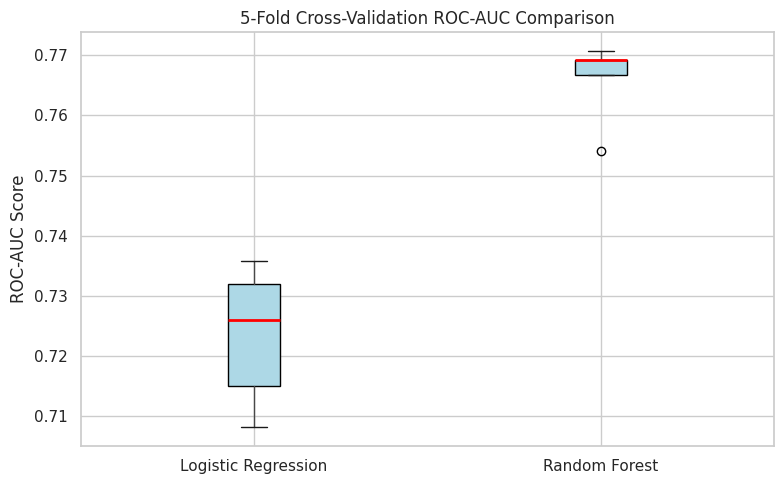

       Logistic Regression  Random Forest
count             5.000000       5.000000
mean              0.723354       0.766001
std               0.011581       0.006786
min               0.708124       0.754142
25%               0.714962       0.766684
50%               0.725997       0.769152
75%               0.731962       0.769316
max               0.735726       0.770712


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
cv_data = pd.DataFrame({
    "Logistic Regression": lr_cv_scores,
    "Random Forest":       rf_cv_scores
})
cv_data.boxplot(ax=ax, vert=True, patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red", linewidth=2))
ax.set_ylabel("ROC-AUC Score")
ax.set_title("5-Fold Cross-Validation ROC-AUC Comparison")
plt.tight_layout()
plt.savefig("06_cv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(cv_data.describe())

### 9-e. Feature Importances (Random Forest — on original features)

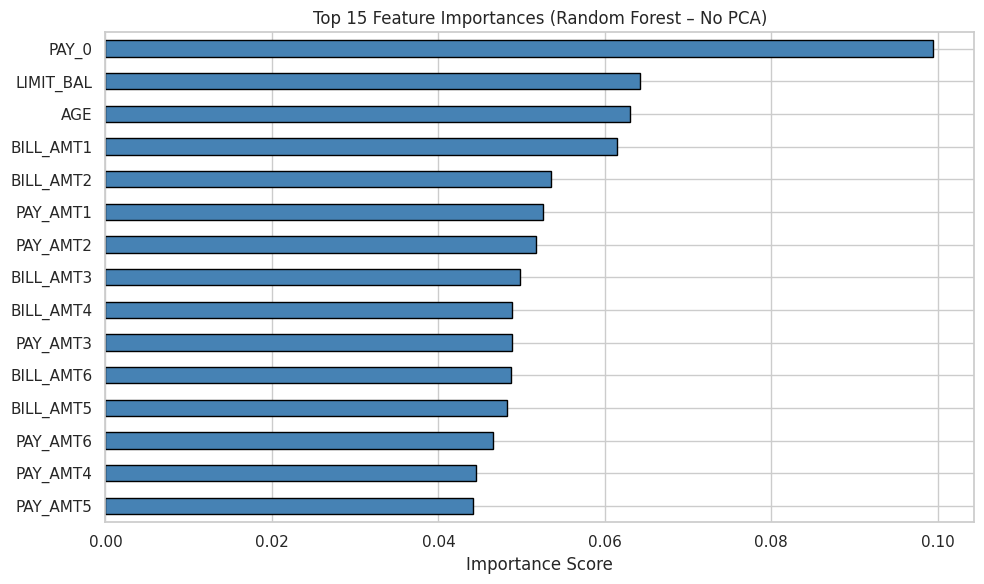

Top 10 features:
PAY_0        0.099381
LIMIT_BAL    0.064263
AGE          0.062987
BILL_AMT1    0.061503
BILL_AMT2    0.053536
PAY_AMT1     0.052531
PAY_AMT2     0.051671
BILL_AMT3    0.049860
BILL_AMT4    0.048812
PAY_AMT3     0.048792
dtype: float64


In [ ]:
rf_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1))
])
rf_no_pca.fit(X_train, y_train)

importances = rf_no_pca.named_steps["clf"].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Top 15 Feature Importances (Random Forest – No PCA)")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("07_feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 features:")
print(feat_imp.head(10))

### 9-f. Learning Curves

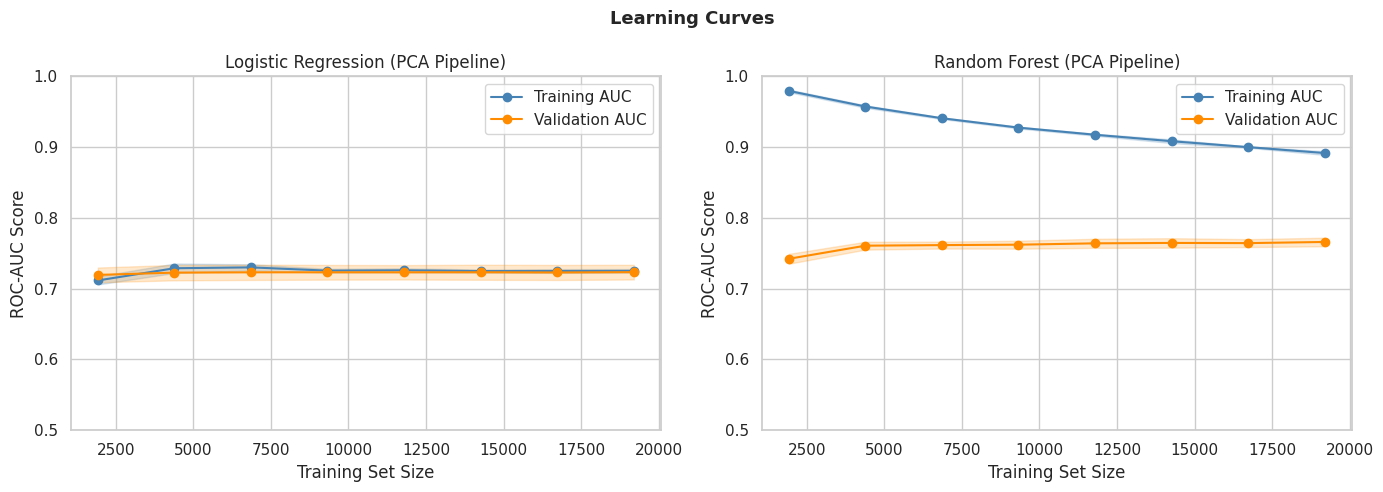

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Learning Curves", fontsize=13, fontweight="bold")

for ax, model, title in zip(
        axes,
        [best_lr, best_rf],
        ["Logistic Regression (PCA Pipeline)", "Random Forest (PCA Pipeline)"]):

    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        cv=cv_strategy, scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, "o-", color="steelblue",  label="Training AUC")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.2, color="steelblue")
    ax.plot(train_sizes, val_mean, "o-", color="darkorange", label="Validation AUC")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.2, color="darkorange")
    ax.set_title(title)
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("ROC-AUC Score")
    ax.legend()
    ax.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig("08_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 9-g. Hyperparameter Tuning Results (Logistic Regression — C)

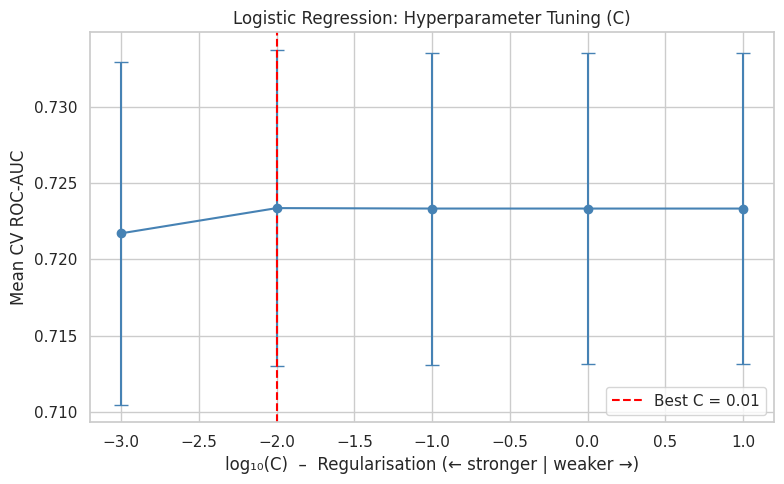

In [ ]:
lr_results = pd.DataFrame(lr_search.cv_results_)
lr_results_plot = lr_results[["param_clf__C", "mean_test_score", "std_test_score"]].copy()
lr_results_plot["param_clf__C"] = lr_results_plot["param_clf__C"].astype(float)
lr_results_plot.sort_values("param_clf__C", inplace=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    np.log10(lr_results_plot["param_clf__C"]),
    lr_results_plot["mean_test_score"],
    yerr=lr_results_plot["std_test_score"],
    marker="o", color="steelblue", capsize=5
)
ax.set_xlabel("log₁₀(C)  –  Regularisation (← stronger | weaker →)")
ax.set_ylabel("Mean CV ROC-AUC")
ax.set_title("Logistic Regression: Hyperparameter Tuning (C)")
ax.axvline(np.log10(lr_search.best_params_["clf__C"]), linestyle="--", color="red",
           label=f"Best C = {lr_search.best_params_['clf__C']}")
ax.legend()
plt.tight_layout()
plt.savefig("09_lr_hyperparameter.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Final Model Comparison Summary

In [ ]:
summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "CV AUC Mean":    [lr_cv_scores.mean(), rf_cv_scores.mean()],
    "CV AUC Std":     [lr_cv_scores.std(),  rf_cv_scores.std()],
    "Test Accuracy":  [lr_acc, rf_acc],
    "Test F1":        [lr_f1,  rf_f1],
    "Test ROC-AUC":   [lr_auc, rf_auc],
})
summary.set_index("Model", inplace=True)
summary.round(4).style.highlight_max(color="lightgreen", axis=0)

,CV AUC Mean,CV AUC Std,Test Accuracy,Test F1,Test ROC-AUC
Model,,,,,
Logistic Regression,0.723400,0.010400,0.681800,0.463600,0.706900
Random Forest,0.766000,0.006100,0.788500,0.522400,0.761900


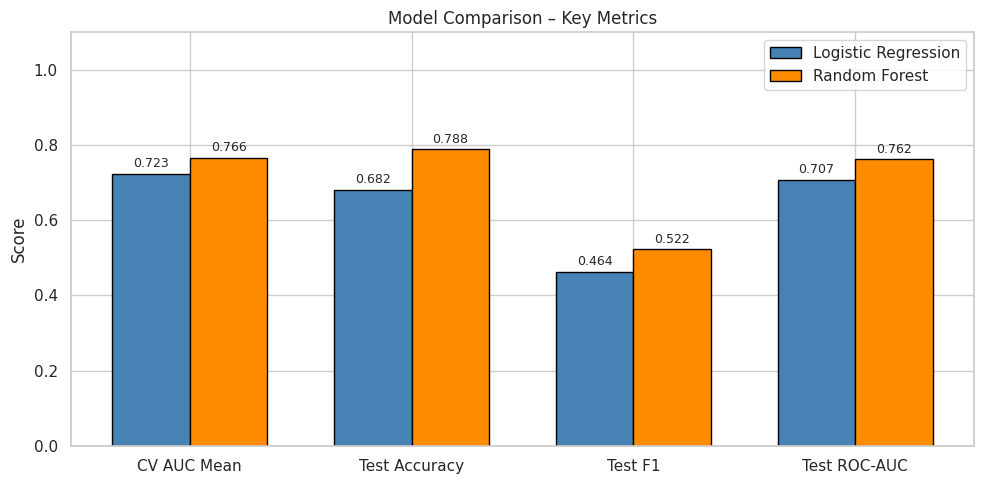


All plots saved successfully!


In [ ]:
# Bar chart comparison
metrics = ["CV AUC Mean", "Test Accuracy", "Test F1", "Test ROC-AUC"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, summary.loc["Logistic Regression", metrics], width,
               label="Logistic Regression", color="steelblue", edgecolor="black")
bars2 = ax.bar(x + width/2, summary.loc["Random Forest", metrics], width,
               label="Random Forest", color="darkorange", edgecolor="black")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Model Comparison – Key Metrics")
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("10_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nAll plots saved successfully!")

# Conclusion

In this project, PCA was applied to dimensionality reduction and then LR and RF models were built to predict credit card default.

Both models were fitted using pipelines with scaling, cross-validation and hyperparameter tuning.

The RF model showed a better performance compared with LR for all the metrics including ROC-AUC, Accuracy and F1-score. This means that RF model can better learn nonlinear pattern in the data.

ROC-AUC is 0.7619 which can be considered as good prediction performance. But F1-score is lower which shows class imbalanced problem in prediction default cases.

The low standard deviations in cross-validation results demonstrate the models perform consistently.

Overall, the preferred model is Random Forest.